In [8]:
from pathlib import Path
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np




In [9]:
# Set path for notebook
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_ROOT = PROJECT_ROOT / "data" / "raw" / "SIDD_Small_sRGB_Only" / "Data"

print("Project root:", PROJECT_ROOT)
print("Dataset root exists:", DATA_ROOT.exists())
print("Dataset root:", DATA_ROOT)

Project root: /Users/Rex/vscode/image_denoising
Dataset root exists: True
Dataset root: /Users/Rex/vscode/image_denoising/data/raw/SIDD_Small_sRGB_Only/Data


In [10]:
# Used a list to sort the folders
scene_folders = sorted([p for p in DATA_ROOT.iterdir() if p.is_dir()])

# Want to check the number of  folders
print("Number of scene folders:", len(scene_folders))
print("\nFirst 10 folders:")

# Go from 0 to 10 folders and print its name
for folder in scene_folders[:10]:
    print(folder.name)

Number of scene folders: 160

First 10 folders:
0001_001_S6_00100_00060_3200_L
0002_001_S6_00100_00020_3200_N
0003_001_S6_00100_00060_3200_H
0004_001_S6_00100_00060_4400_L
0005_001_S6_00100_00060_4400_N
0006_001_S6_00100_00060_4400_H
0007_001_S6_00100_00100_5500_L
0008_001_S6_00100_00100_5500_N
0010_001_S6_00800_00350_3200_N
0011_001_S6_00800_00500_5500_L


In [11]:
example_folder = scene_folders[0]

print("Example folder:", example_folder.name)
print("\nFiles inside:")

for item in sorted(example_folder.iterdir()):
    print(item.name)

Example folder: 0001_001_S6_00100_00060_3200_L

Files inside:
GT_SRGB_010.PNG
NOISY_SRGB_010.PNG


In [12]:
image_extensions = {".png", ".jpg", ".jpeg", ".tif", ".tiff"}

# DATA_ROOT here is the folder root
# will hold the files in a list comprehension
image_files = [
    p for p in DATA_ROOT.rglob("*")
    if p.is_file() and p.suffix.lower() in image_extensions
]

print("Total image files:", len(image_files))

# Turn into a series and caount it
pd.Series([p.suffix.lower() for p in image_files]).value_counts()

Total image files: 320


.png    320
Name: count, dtype: int64

In [13]:
example_images = sorted([
    p for p in example_folder.rglob("*")
    if p.is_file() and p.suffix.lower() in image_extensions
])

print("Images in example folder:", len(example_images))

for p in example_images:
    print(p.name)

Images in example folder: 2
GT_SRGB_010.PNG
NOISY_SRGB_010.PNG


In SIDD, the noise is often subtle, not cartoonishly obvious. It’s real smartphone noise, so sometimes the pair can look almost identical at first glance

GT shape: (3000, 5328, 3)
Noisy shape: (3000, 5328, 3)
Mean absolute pixel difference: 5.145762
Max absolute pixel difference: 79.0


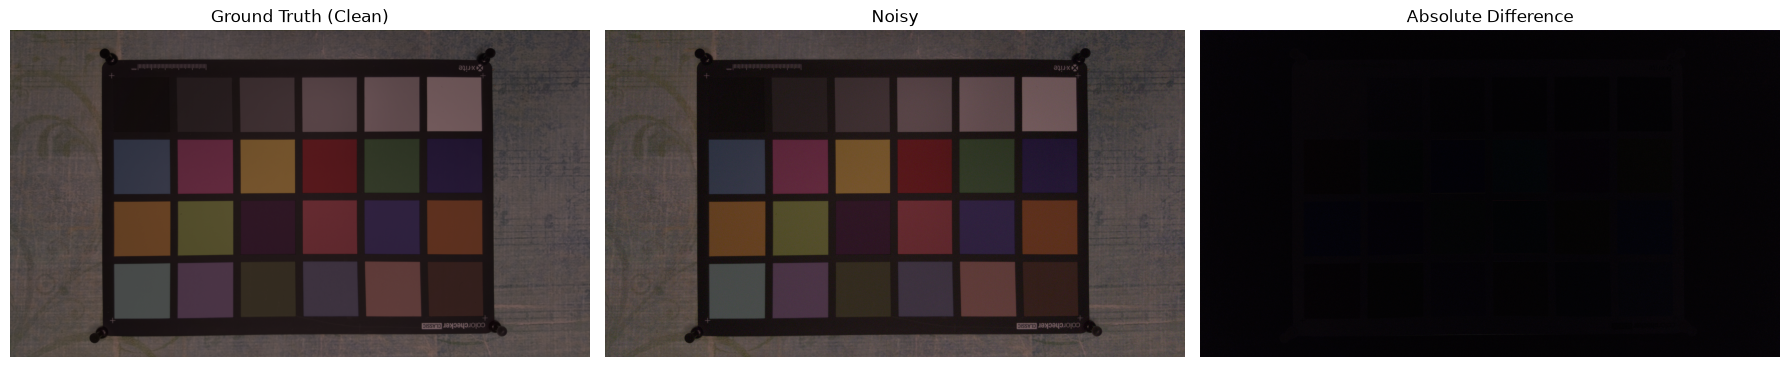

In [ ]:
# Grab the GT and NOISY images from the example folder
gt_path = [p for p in example_images if "GT" in p.name][0]
noisy_path = [p for p in example_images if "NOISY" in p.name][0]

gt_img = np.array(Image.open(gt_path).convert("RGB")).astype(np.float32)
noisy_img = np.array(Image.open(noisy_path).convert("RGB")).astype(np.float32)

diff_img = np.abs(noisy_img - gt_img)

print("GT shape:", gt_img.shape)
print("Noisy shape:", noisy_img.shape)
print("Mean absolute pixel difference:", diff_img.mean())
print("Max absolute pixel difference:", diff_img.max())

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.imshow(gt_img.astype(np.uint8))
plt.title("Ground Truth (Clean)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(noisy_img.astype(np.uint8))
plt.title("Noisy")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(diff_img.astype(np.uint8))
plt.title("Absolute Difference")
plt.axis("off")

plt.tight_layout()
plt.show()

Shapes match: good, so noisy/GT are aligned pairs.

Mean absolute pixel difference ≈ 5.15: the noisy image is close to the clean one, but definitely different.

Max absolute difference = 79: some pixels differ a lot, which is what is needed for a denoising task.

In SIDD, the noise is often subtle, not cartoonishly obvious. It’s real smartphone noise, so sometimes the pair can look almost identical at first glance

This confirms the dataset contains subtle real smartphone noise, not exaggerated synthetic noise.

Because the noisy and GT images are aligned, PSNR and SSIM are valid metrics for evaluation.

The model’s goal is to reduce the noisy image toward the GT image while preserving texture, edges, and color.